# real2_WineQuality: Default BART vs Parallel Tempering BART

This notebook uses `diagnosis/pt/experiment.py` to run multi-run, multi-chain experiments.
- Different runs: different train/test splits
- Same run, different chains: same split, different random seeds
- PT temperatures are selected by quick ladder search before each run

In [1]:
import os, certifi
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

import os
import sys
from pathlib import Path

ROOT = Path(os.getcwd()).resolve().parents[1]  # bart-playground root
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

notebook = "real2_WineQuality_pt"

In [2]:
import numpy as np
from ucimlrepo import fetch_ucirepo

# Load WineQuality dataset
winequality = fetch_ucirepo(id=186)
X = winequality.data.features.values.astype(float)
y = np.asarray(winequality.data.targets).reshape(-1)

X.shape, y.shape

((6497, 11), (6497,))

In [3]:
from experiment import run_parallel_experiments

ndpost = 10000
nskip = 5000
n_trees = 1

# You can scale these up for final experiments
n_runs = 5
n_chains = 5
n_jobs = 5

results = run_parallel_experiments(
    X=X,
    y=y,
    ndpost=ndpost,
    nskip=nskip,
    n_trees=n_trees,
    notebook=notebook,
    n_runs=n_runs,
    n_chains=n_chains,
    n_jobs=n_jobs,
    store_preds=True,
    n_test_points=100,
    swap_interval=50,
    ladder_target_rate=0.4,
    ladder_max_rounds=10,
    ladder_ndpost=500,
    ladder_nskip=100,
    ladder_repeats=3,
    ladder_search_points=500,
    ladder_initial_temperatures=(1.0, 2.0, 3.0, 5.0),
    store_dir="store",
    progress_print=True,
)

print(f"Finished. Stored CSV files under: {Path('store').resolve()}")

[RUN 0] start (1/5) | split_seed=42
[LADDER] start: n_points=500, rounds<=10, repeats=3, target_rate=0.4, init_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] round 1/10: n_temps=4, mean_rates=[0.6, 0.7556, 0.6667]
[LADDER] stop: target reached or no valid rates. final_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] done: final n_temps=4
[RUN 0] ladder selected temps=[1.0, 2.0, 3.0, 5.0]
[RUN 0] chains start: n_chains=5


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:  1.2min remaining:  1.8min
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:  1.2min remaining:   48.2s
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:  1.2min finished


[RUN 0] done and saved to store
[RUN 1] start (2/5) | split_seed=43
[LADDER] start: n_points=500, rounds<=10, repeats=3, target_rate=0.4, init_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] round 1/10: n_temps=4, mean_rates=[0.6889, 0.7111, 0.5333]
[LADDER] stop: target reached or no valid rates. final_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] done: final n_temps=4
[RUN 1] ladder selected temps=[1.0, 2.0, 3.0, 5.0]
[RUN 1] chains start: n_chains=5


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:   53.5s remaining:  1.3min
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:   56.0s remaining:   37.3s
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:  1.1min finished


[RUN 1] done and saved to store
[RUN 2] start (3/5) | split_seed=44
[LADDER] start: n_points=500, rounds<=10, repeats=3, target_rate=0.4, init_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] round 1/10: n_temps=4, mean_rates=[0.6889, 0.6889, 0.6222]
[LADDER] stop: target reached or no valid rates. final_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] done: final n_temps=4
[RUN 2] ladder selected temps=[1.0, 2.0, 3.0, 5.0]
[RUN 2] chains start: n_chains=5


...

[RUN 2] done and saved to store
[RUN 3] start (4/5) | split_seed=45
[LADDER] start: n_points=500, rounds<=10, repeats=3, target_rate=0.4, init_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] round 1/10: n_temps=4, mean_rates=[0.7111, 0.7778, 0.5556]
[LADDER] stop: target reached or no valid rates. final_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] done: final n_temps=4
[RUN 3] ladder selected temps=[1.0, 2.0, 3.0, 5.0]
[RUN 3] chains start: n_chains=5


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:   56.1s remaining:  1.4min
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:   56.4s remaining:   37.6s
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:  1.0min finished


[RUN 3] done and saved to store
[RUN 4] start (5/5) | split_seed=46
[LADDER] start: n_points=500, rounds<=10, repeats=3, target_rate=0.4, init_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] round 1/10: n_temps=4, mean_rates=[0.6444, 0.7333, 0.7778]
[LADDER] stop: target reached or no valid rates. final_temps=[1.0, 2.0, 3.0, 5.0]
[LADDER] done: final n_temps=4
[RUN 4] ladder selected temps=[1.0, 2.0, 3.0, 5.0]
[RUN 4] chains start: n_chains=5


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:  1.4min remaining:  2.1min
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:  1.4min remaining:   55.1s
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:  1.4min finished


[RUN 4] done and saved to store
Finished. Stored CSV files under: C:\Users\ztykk\Phd\BART\bart-playground\diagnosis\pt_1tree\store


In [4]:
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

# Used only for downstream plots (PCA/trace).
SELECT_RUN_ID = 0
SELECT_CHAIN_ID = 0
TABPFN_RANDOM_STATE = 42

def crps_from_samples(samples, y_true):
    """CRPS from posterior samples.

    samples: (n_points, n_samples)
    y_true:  (n_points,)
    """
    n_points, n_samples = samples.shape
    term1 = np.mean(np.abs(samples - y_true[:, None]), axis=1)
    samples_sorted = np.sort(samples, axis=1)
    k = np.arange(1, n_samples + 1)
    coeffs = (2 * k - n_samples - 1)[None, :]
    term2 = np.sum(coeffs * samples_sorted, axis=1) / (n_samples ** 2)
    return term1 - term2

def ensure_point_by_sample(arr, n_points):
    """Ensure array is (n_points, n_samples)."""
    arr = np.asarray(arr, dtype=float)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D array, got shape={arr.shape}")
    if arr.shape[0] == n_points:
        return arr
    if arr.shape[1] == n_points:
        return arr.T
    raise ValueError(f"Could not align samples with n_points={n_points}, shape={arr.shape}")

from tabpfn import TabPFNRegressor

rows_rmse = []
rows_crps = []
run_cache = {}

for run in results:
    run_id = int(run["run_id"])

    split_seed = int(run["split_seed"])


    # Keep split identical across compared methods inside each run.
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=split_seed)
    X_test_sub = np.asarray(run["subsample"]["X_test"], dtype=float)
    y_test_sub = np.asarray(run["subsample"]["y_test"], dtype=float).reshape(-1)

    # ---- Default BART: average metrics over chains ----
    default_chain_rmse = []
    default_chain_crps = []
    for chain_pred in run["default"]["preds"]:
        samples = ensure_point_by_sample(chain_pred, n_points=y_test_sub.shape[0])
        pred_mean = np.mean(samples, axis=1)
        default_chain_rmse.append(root_mean_squared_error(y_test_sub, pred_mean))
        default_chain_crps.append(float(np.mean(crps_from_samples(samples, y_test_sub))))

    # ---- PT BART: average metrics over chains ----
    pt_chain_rmse = []
    pt_chain_crps = []
    for chain_pred in run["pt"]["preds"]:
        samples = ensure_point_by_sample(chain_pred, n_points=y_test_sub.shape[0])
        pred_mean = np.mean(samples, axis=1)
        pt_chain_rmse.append(root_mean_squared_error(y_test_sub, pred_mean))
        pt_chain_crps.append(float(np.mean(crps_from_samples(samples, y_test_sub))))

    # ---- TabPFN: point prediction only (once per run) ----
    tabpfn_model = TabPFNRegressor(
        random_state=TABPFN_RANDOM_STATE,
        ignore_pretraining_limits=True,
    )
    tabpfn_model.fit(X_train, y_train)
    tabpfn_mean = np.asarray(tabpfn_model.predict(X_test_sub), dtype=float).reshape(-1)
    tabpfn_rmse = root_mean_squared_error(y_test_sub, tabpfn_mean)

    rows_rmse.append(
        {
            "run_id": run_id,
            "default bart": float(np.mean(default_chain_rmse)),
            "pt": float(np.mean(pt_chain_rmse)),
            "tabpfn": float(tabpfn_rmse),
        }
    )
    rows_crps.append(
        {
            "run_id": run_id,
            "default bart": float(np.mean(default_chain_crps)),
            "pt": float(np.mean(pt_chain_crps)),
        }
    )

    run_cache[run_id] = {
        "selected_run": run,
        "split_seed": split_seed,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "X_test_sub": X_test_sub,
        "y_test_sub": y_test_sub,
        "tabpfn_mean": tabpfn_mean,
    }

rmse_table = pd.DataFrame(rows_rmse).sort_values("run_id").set_index("run_id")
crps_table = pd.DataFrame(rows_crps).sort_values("run_id").set_index("run_id")

print("RMSE table (rows=runs, cols=models):")
display(rmse_table)
print("\nCRPS table (rows=runs, cols=models; tabpfn excluded):")
display(crps_table)

# Variables for downstream plotting cells.
if SELECT_RUN_ID not in run_cache:
    raise ValueError(f"SELECT_RUN_ID={SELECT_RUN_ID} not found in available runs: {sorted(run_cache.keys())}")

selected_run = run_cache[SELECT_RUN_ID]["selected_run"]
X_train = run_cache[SELECT_RUN_ID]["X_train"]
X_test = run_cache[SELECT_RUN_ID]["X_test"]
y_train = run_cache[SELECT_RUN_ID]["y_train"]
y_test = run_cache[SELECT_RUN_ID]["y_test"]
X_test_sub = run_cache[SELECT_RUN_ID]["X_test_sub"]
y_test_sub = run_cache[SELECT_RUN_ID]["y_test_sub"]
tabpfn_mean = run_cache[SELECT_RUN_ID]["tabpfn_mean"]

default_samples = ensure_point_by_sample(
    selected_run["default"]["preds"][SELECT_CHAIN_ID],
    n_points=y_test_sub.shape[0],
)
pt_samples = ensure_point_by_sample(
    selected_run["pt"]["preds"][SELECT_CHAIN_ID],
    n_points=y_test_sub.shape[0],
)

rmse_default = root_mean_squared_error(y_test_sub, np.mean(default_samples, axis=1))
rmse_pt = root_mean_squared_error(y_test_sub, np.mean(pt_samples, axis=1))
rmse_tabpfn = root_mean_squared_error(y_test_sub, tabpfn_mean)
crps_default = float(np.mean(crps_from_samples(default_samples, y_test_sub)))
crps_pt = float(np.mean(crps_from_samples(pt_samples, y_test_sub)))

print(f"\nFor downstream plots: selected run={SELECT_RUN_ID}, chain={SELECT_CHAIN_ID}")
print("Shapes -> default:", default_samples.shape, "pt:", pt_samples.shape, "tabpfn_mean:", tabpfn_mean.shape)

RMSE table (rows=runs, cols=models):


,default bart,pt,tabpfn
run_id,,,
0,0.748178,0.750501,0.576445
1,0.760545,0.772478,0.676278
2,0.739070,0.748774,0.642122
3,0.730371,0.734147,0.544820
4,0.627234,0.620293,0.526170



CRPS table (rows=runs, cols=models; tabpfn excluded):


,default bart,pt
run_id,,
0,0.539703,0.503564
1,0.541179,0.525637
2,0.553334,0.540146
3,0.546945,0.527360
4,0.450179,0.437328



For downstream plots: selected run=0, chain=0
Shapes -> default: (100, 10000) pt: (100, 10000) tabpfn_mean: (100,)


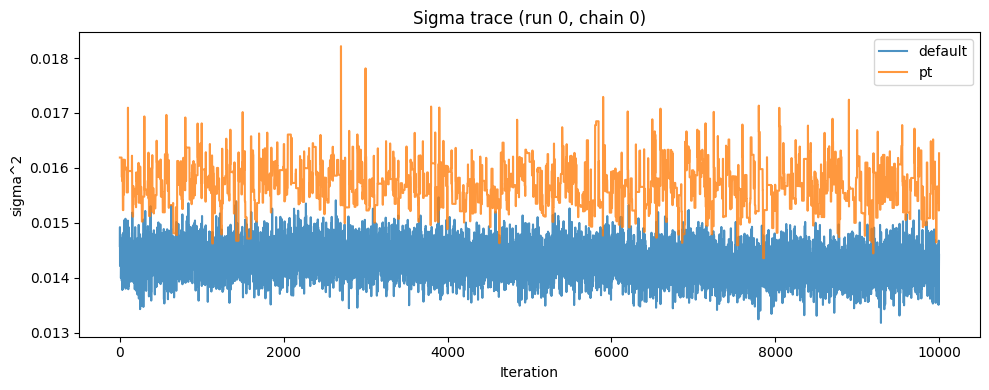

In [5]:
import matplotlib.pyplot as plt

# Sigma trace for selected run/chain
sigma_default = np.asarray(selected_run["default"]["sigmas"][SELECT_CHAIN_ID]).reshape(-1)
sigma_pt = np.asarray(selected_run["pt"]["sigmas"][SELECT_CHAIN_ID]).reshape(-1)

plt.figure(figsize=(10, 4))
plt.plot(sigma_default, label="default", alpha=0.8)
plt.plot(sigma_pt, label="pt", alpha=0.8)
plt.xlabel("Iteration")
plt.ylabel("sigma^2")
plt.title(f"Sigma trace (run {SELECT_RUN_ID}, chain {SELECT_CHAIN_ID})")
plt.legend()
plt.tight_layout()
plt.show()

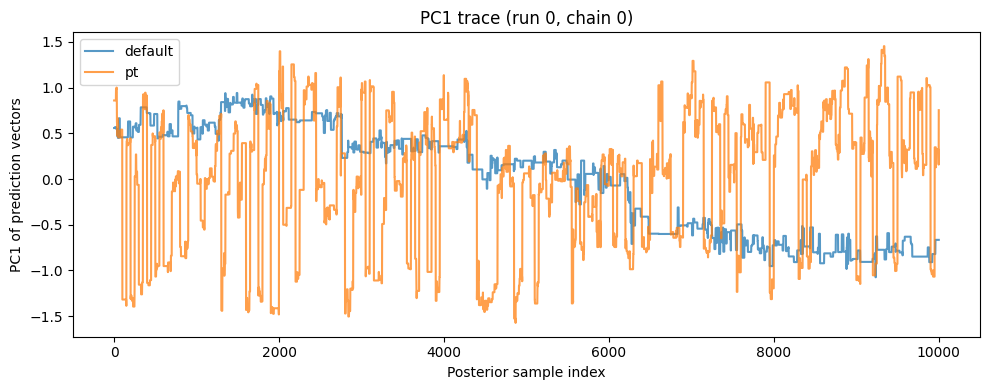

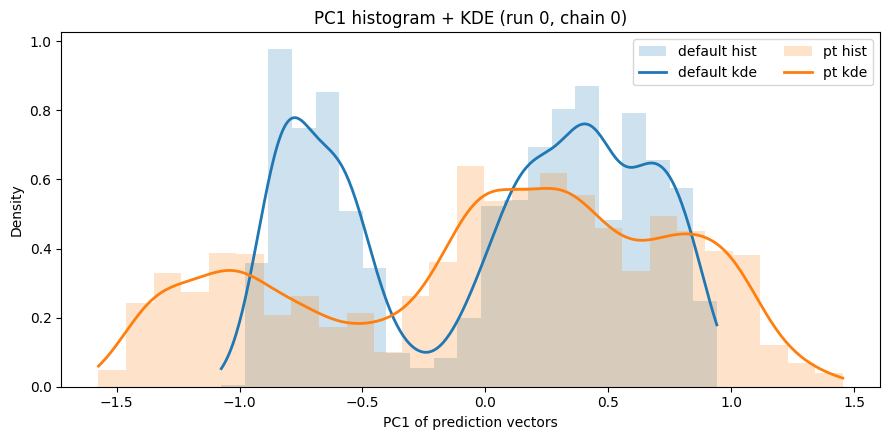

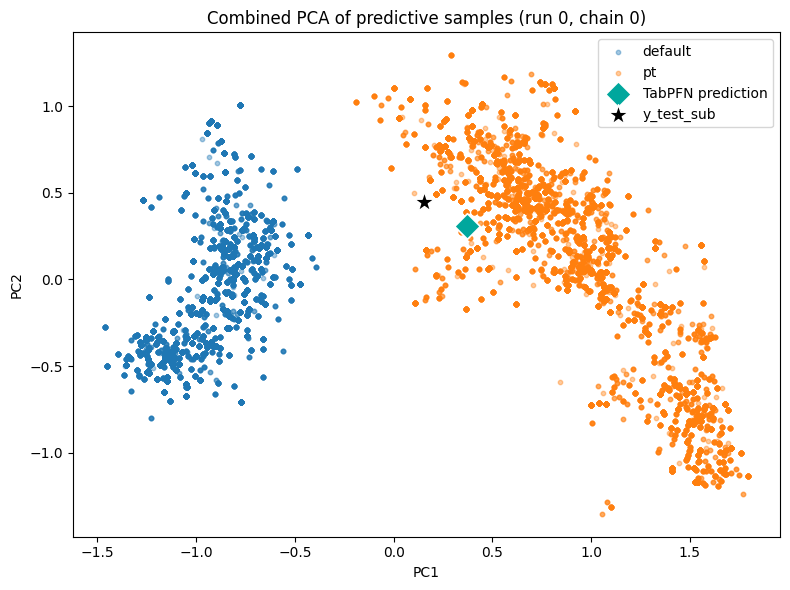

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Build sample vectors: each posterior draw is one vector over test points.
# Input shapes are (n_points, n_samples); convert to (n_samples, n_points).
X_default_vec = default_samples.T
X_pt_vec = pt_samples.T

# PC1 trace plot (default and pt only).
pc1_default = PCA(n_components=1).fit_transform(X_default_vec)[:, 0]
pc1_pt = PCA(n_components=1).fit_transform(X_pt_vec)[:, 0]

plt.figure(figsize=(10, 4))
plt.plot(pc1_default, label="default", alpha=0.75)
plt.plot(pc1_pt, label="pt", alpha=0.75)
plt.xlabel("Posterior sample index")
plt.ylabel("PC1 of prediction vectors")
plt.title(f"PC1 trace (run {SELECT_RUN_ID}, chain {SELECT_CHAIN_ID})")
plt.legend()
plt.tight_layout()
plt.show()

# PC1 histogram + KDE in one figure.
plt.figure(figsize=(9, 4.5))
for arr, name, color in [
    (pc1_default, "default", "tab:blue"),
    (pc1_pt, "pt", "tab:orange"),
]:
    plt.hist(arr, bins="auto", density=True, alpha=0.22, color=color, label=f"{name} hist")
    x_grid = np.linspace(np.min(arr), np.max(arr), 300)
    kde = gaussian_kde(arr)
    plt.plot(x_grid, kde(x_grid), color=color, linewidth=2.0, label=f"{name} kde")

plt.xlabel("PC1 of prediction vectors")
plt.ylabel("Density")
plt.title(f"PC1 histogram + KDE (run {SELECT_RUN_ID}, chain {SELECT_CHAIN_ID})")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

# Combined PCA: PC1 vs PC2 scatter for default and pt predictive distributions.
X_combined = np.vstack([X_default_vec, X_pt_vec])
labels = np.array(
    ["default"] * len(X_default_vec)
    + ["pt"] * len(X_pt_vec)
)

pca2 = PCA(n_components=2)
pc2 = pca2.fit_transform(X_combined)

plt.figure(figsize=(8, 6))
for name, color in [("default", "tab:blue"), ("pt", "tab:orange")]:
    mask = labels == name
    plt.scatter(pc2[mask, 0], pc2[mask, 1], s=10, alpha=0.4, c=color, label=name)

# Draw tabpfn point prediction and y_test_sub point only on this plot.
tabpfn_mean_proj = pca2.transform(tabpfn_mean.reshape(1, -1))[0]
y_proj = pca2.transform(y_test_sub.reshape(1, -1))[0]
plt.scatter(
    tabpfn_mean_proj[0],
    tabpfn_mean_proj[1],
    s=170,
    c="#00A79D",
    marker="D",
    edgecolors="white",
    linewidths=1.2,
    zorder=7,
    label="TabPFN prediction",
)
plt.scatter(
    y_proj[0],
    y_proj[1],
    s=240,
    c="black",
    marker="*",
    edgecolors="white",
    linewidths=1.1,
    zorder=8,
    label="y_test_sub",
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Combined PCA of predictive samples (run {SELECT_RUN_ID}, chain {SELECT_CHAIN_ID})")
plt.legend()
plt.tight_layout()
plt.show()